## 种类

### 基础图
1. 折线图、趋势图
2. 柱状图、条形图
3. 饼图、环形图
4. 散点图、气泡图

### 高级
1. 热力图、相关性图
2. 坐标图、雷达图
3. 树形图、层次图



## 1. 折线图与趋势图

| 图表类型 | 适用场景 |
|---------|----------|
| **折线图** | 展示数据随时间的变化趋势，如股票价格、气温变化、网站访问量随时间演变的规律。 |
| **趋势图** | 强调数据的长期走向、周期性或波动特征，常配合平滑线或移动平均线使用，如GDP增长率、季节性销售模式。 |

## 2. 柱状图与条形图

| 图表类型 | 适用场景 |
|---------|----------|
| **柱状图** | 比较不同类别的数值大小，如各产品销量、不同地区人口数。适合类别较少（<12）且类别名称较短的情况。 |
| **条形图** | 与柱状图同理，但类别轴为垂直方向，适合类别名称较长或类别数量较多时的横向比较，如调查问卷选项得分排名。 |

## 3. 饼图与环形图

| 图表类型 | 适用场景 |
|---------|----------|
| **饼图** | 展示各部分占整体的比例，强调“部分与整体”的关系，通常用于2~5个类别的构成分析。 |
| **环形图** | 与饼图功能相同，但中心留白可额外标注汇总信息（如总金额、平均值），视觉上更简洁，适合多类别时的比较。 |

## 4. 散点图与气泡图

| 图表类型 | 适用场景 |
|---------|----------|
| **散点图** | 探究两个连续变量之间的关系（正/负相关、聚类、离群点），如身高与体重、广告投入与销售额。 |
| **气泡图** | 在散点图基础上增加第三个变量（气泡大小），用于三维数据的对比，如国家GDP（X）、人均寿命（Y）、人口（气泡大小）。 |



C:\Users\seama\AppData\Local\Temp\ipykernel_56388\928449702.py:24: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['环比增长率'].fillna(0, inplace=True)


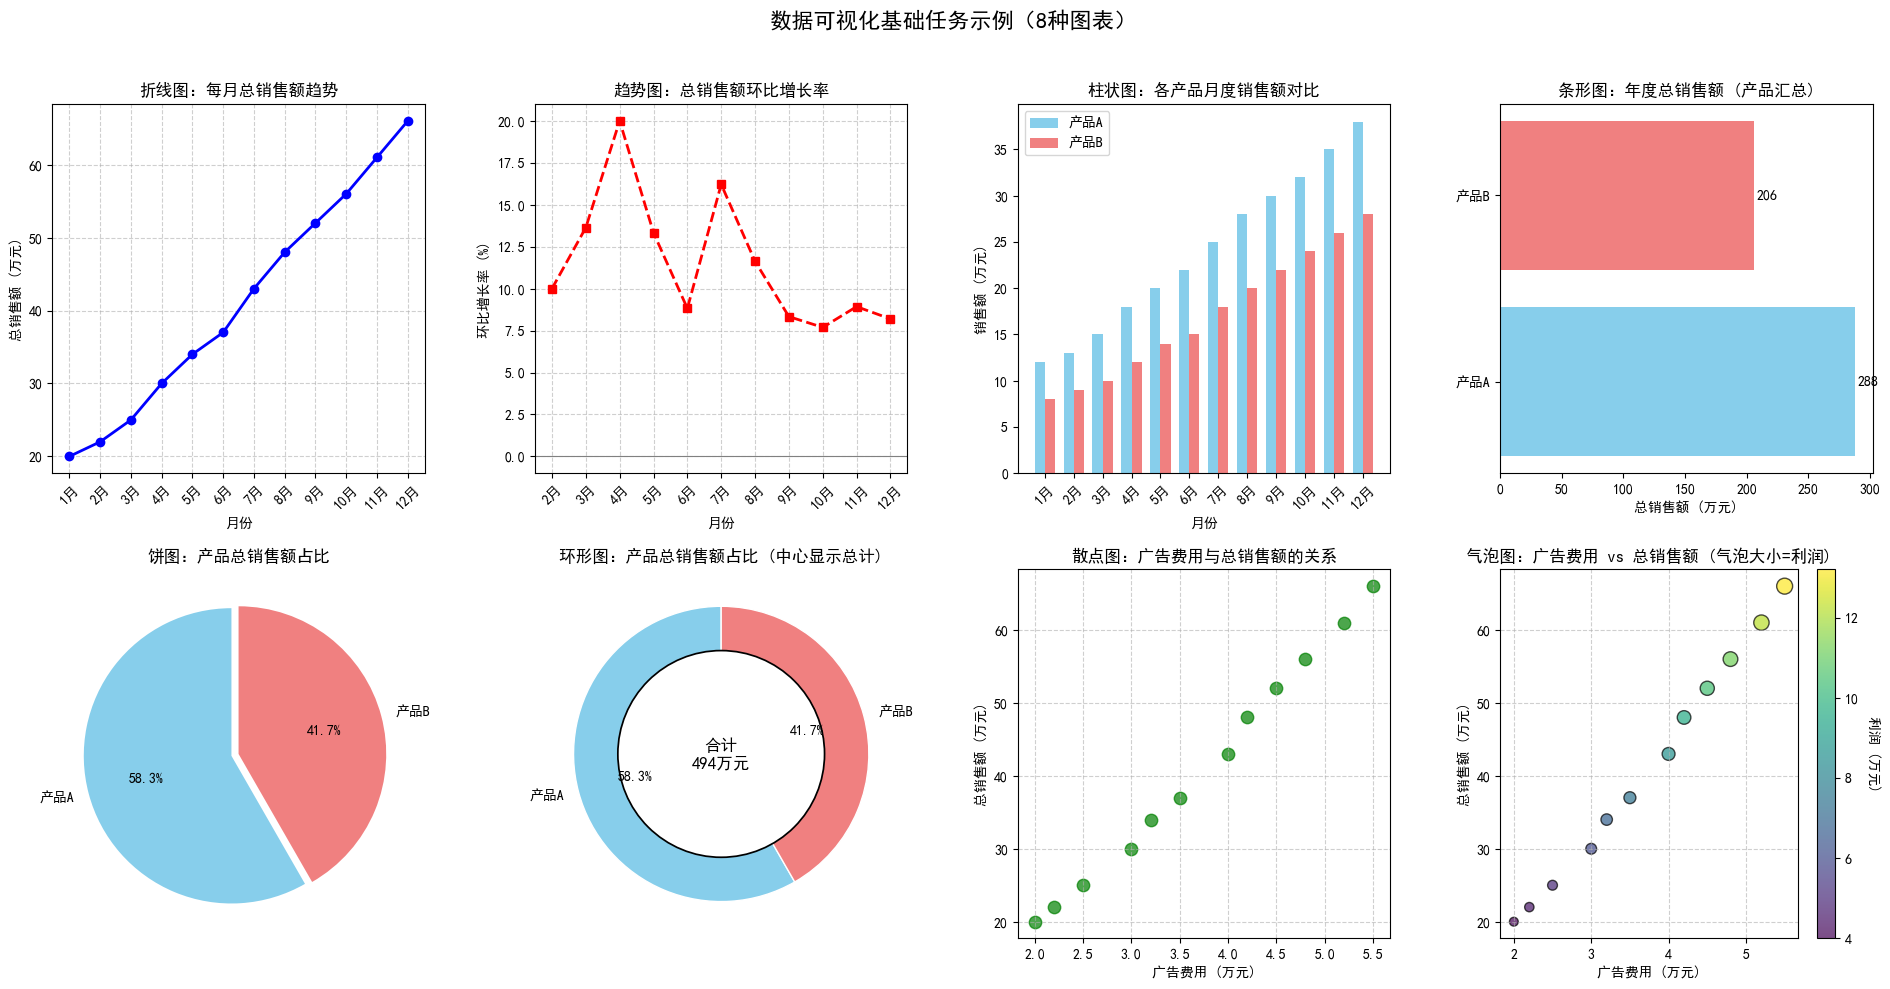

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns

# 设置中文显示（避免乱码，根据实际环境调整）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 1. 准备数据 ----------
data = {
    '月份': ['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月'],
    '产品A销售额': [12, 13, 15, 18, 20, 22, 25, 28, 30, 32, 35, 38],
    '产品B销售额': [8, 9, 10, 12, 14, 15, 18, 20, 22, 24, 26, 28],
    '总销售额': [20, 22, 25, 30, 34, 37, 43, 48, 52, 56, 61, 66],
    '广告费用': [2.0, 2.2, 2.5, 3.0, 3.2, 3.5, 4.0, 4.2, 4.5, 4.8, 5.2, 5.5],
    '利润': [4.0, 4.5, 5.0, 6.0, 6.8, 7.4, 8.6, 9.6, 10.4, 11.2, 12.2, 13.2]
}
df = pd.DataFrame(data)

# 计算环比增长率（趋势图用）
df['环比增长率'] = df['总销售额'].pct_change() * 100
df['环比增长率'].fillna(0, inplace=True)

# 产品总销售额（饼图/环形图用）
total_A = df['产品A销售额'].sum()
total_B = df['产品B销售额'].sum()
pie_data = [total_A, total_B]
pie_labels = ['产品A', '产品B']

# 气泡图数据准备（第三维：利润）
bubble_sizes = df['利润'] * 10   # 缩放系数便于显示

# ---------- 2. 创建画布（8个子图，2行4列） ----------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.tight_layout(pad=5.0)

# ----- 第一行：折线图、趋势图、柱状图、条形图 -----
# 2.1 折线图：每月总销售额变化
ax = axes[0, 0]
ax.plot(df['月份'], df['总销售额'], marker='o', linestyle='-', color='b', linewidth=2)
ax.set_title('折线图：每月总销售额趋势', fontsize=12)
ax.set_xlabel('月份')
ax.set_ylabel('总销售额 (万元)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# 2.2 趋势图：环比增长率（带参考线）
ax = axes[0, 1]
ax.plot(df['月份'], df['环比增长率'], marker='s', linestyle='--', color='r', linewidth=2)
ax.axhline(0, color='gray', linestyle='-', linewidth=0.8)
ax.set_title('趋势图：总销售额环比增长率', fontsize=12)
ax.set_xlabel('月份')
ax.set_ylabel('环比增长率 (%)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# 2.3 柱状图：每月产品A与产品B销售额（分组柱状）
ax = axes[0, 2]
x = np.arange(len(df['月份']))
width = 0.35
bars1 = ax.bar(x - width/2, df['产品A销售额'], width, label='产品A', color='skyblue')
bars2 = ax.bar(x + width/2, df['产品B销售额'], width, label='产品B', color='lightcoral')
ax.set_title('柱状图：各产品月度销售额对比', fontsize=12)
ax.set_xlabel('月份')
ax.set_ylabel('销售额 (万元)')
ax.set_xticks(x)
ax.set_xticklabels(df['月份'], rotation=45)
ax.legend()

# 2.4 条形图：年度总销售额（水平条，按产品A和产品B汇总）
ax = axes[0, 3]
annual_total = [total_A, total_B]
y_pos = ['产品A', '产品B']
ax.barh(y_pos, annual_total, color=['skyblue', 'lightcoral'])
ax.set_title('条形图：年度总销售额 (产品汇总)', fontsize=12)
ax.set_xlabel('总销售额 (万元)')
for i, v in enumerate(annual_total):
    ax.text(v + 2, i, str(v), va='center')

# ----- 第二行：饼图、环形图、散点图、气泡图 -----
# 2.5 饼图：产品总销售额占比
ax = axes[1, 0]
ax.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90, 
       colors=['skyblue', 'lightcoral'], explode=(0.05, 0))
ax.set_title('饼图：产品总销售额占比', fontsize=12)

# 2.6 环形图：相同数据，中心加总金额
ax = axes[1, 1]
wedges, texts, autotexts = ax.pie(pie_data, labels=pie_labels, autopct='%1.1f%%',
                                   startangle=90, colors=['skyblue', 'lightcoral'],
                                   wedgeprops=dict(width=0.5, edgecolor='w'))
# 添加中心圆环效果
centre_circle = Circle((0,0), 0.7, fc='white', linewidth=1.25, edgecolor='black')
ax.add_artist(centre_circle)
ax.text(0, 0, f'合计\n{total_A+total_B}万元', ha='center', va='center', fontsize=12, fontweight='bold')
ax.set_title('环形图：产品总销售额占比 (中心显示总计)', fontsize=12)

# 2.7 散点图：广告费用 vs 总销售额
ax = axes[1, 2]
ax.scatter(df['广告费用'], df['总销售额'], color='green', alpha=0.7, s=80)
ax.set_title('散点图：广告费用与总销售额的关系', fontsize=12)
ax.set_xlabel('广告费用 (万元)')
ax.set_ylabel('总销售额 (万元)')
ax.grid(True, linestyle='--', alpha=0.6)

# 2.8 气泡图：广告费用 vs 总销售额 (气泡大小=利润)
ax = axes[1, 3]
sc = ax.scatter(df['广告费用'], df['总销售额'], s=bubble_sizes, 
                c=df['利润'], cmap='viridis', alpha=0.7, edgecolors='black')
ax.set_title('气泡图：广告费用 vs 总销售额 (气泡大小=利润)', fontsize=12)
ax.set_xlabel('广告费用 (万元)')
ax.set_ylabel('总销售额 (万元)')
# 添加颜色条表示利润
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('利润 (万元)', rotation=270, labelpad=15)
ax.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('数据可视化基础任务示例（8种图表）', fontsize=16, y=1.02)
plt.show()

# 可选：保存图片
# fig.savefig('data_visualization_examples.png', dpi=300, bbox_inches='tight')